In [29]:
# ===========================
# TOÀN BỘ SETUP CHO NOTEBOOK
# ===========================

import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

# Thêm đường dẫn gốc để import src
sys.path.append(os.path.abspath('..'))

# Import các module từ src
from src.config import (
    CITIES,
    FEATURE_COLUMNS,
    TARGET_COLUMNS,
    MODEL_CONFIGS,
    MODELS_DIR,
    PROCESSED_DATA_FILE,
    FIGURES_DIR
)

from src.utils.helpers import (
    load_pickle,
    print_section_header
)

from src.data.load_data import (
    fetch_weather_data_from_api,
    load_raw_data,
    validate_data,
    print_data_info
)

from src.data.preprocess import (
    clean_data,
    handle_outliers,
    validate_data_status
)

from src.features.feature_engineering import (
    create_all_features,
    save_processed_data
)

from src.analysis.python_analysis import (
    get_descriptive_stats, 
    check_normality_jb, 
    analyze_city_variance_manual
)

from src.data.sql_analysis import (
    run_sql_eda
)

from src.visualization.plots import (
    setup_dark_theme,
    plot_model_comparison,
    plot_temperature_by_city,
    plot_temperature_distribution,
    plot_correlation_heatmap,
    plot_seasonal_patterns,
    plot_city_comparison_trend
)

from src.models.train_models import (
    train_all_models,
    save_all_models,
    print_evaluation_summary
)

from src.models.predict import (
    load_all_models,
    load_scalers,
    load_evaluation_metrics
)

from src.dashboard.prepare_tableau import (
    generate_tableau_dataset
)

# Đặt dark theme cho các biểu đồ
setup_dark_theme()

print_section_header("HOÀN THÀNH SETUP CHO NOTEBOOK")


                    HOÀN THÀNH SETUP CHO NOTEBOOK                     



---
# GIỚI THIỆU DỰ ÁN
---

## 1.1 Bối cảnh thực tiễn

Trong những thập kỷ gần đây, biến đổi khí hậu không còn là một dự báo xa vời mà đã trở thành thực tại hiện hữu với những biến động cực đoan gây thiệt hại đáng kể cho các lĩnh vực khác nhau trên toàn cầu. Theo báo cáo từ IPCC (Intergovernmental Panel on Climate Change), Châu Âu là khu vực ảnh hưởng nghiêm trọng nhất do có tốc độ nóng lên nhanh nhất thế giới, với mức tăng nhiệt độ cao gấp đôi so với trung bình toàn cầu kể từ năm 1980.

Sự gia tăng nhiệt độ này không diễn ra tuyến tính mà kèm theo các hình thái thời tiết phức tạp, gây áp lực lên các hệ thống dự báo truyền thống. Việc xây dựng một mô hình học máy (Machine Learning) có khả năng tự thích nghi và dự báo chính xác các chỉ số nhiệt độ (TempMax, TempMean, TempMin) là yêu cầu cấp thiết để tăng cường khả năng chống chịu khí hậu (Climate Resilience) trên toàn cầu.

## 1.2 Phát biểu bài toán

Bài toán trung tâm của dự án là thiết kế và phát triển một kiến trúc **Dự báo linh hoạt** có khả năng thích ứng với các đặc trưng khí hậu khác nhau trên toàn cầu. Thay vì xây dựng một mô hình cứng nhắc cho một khu vực duy nhất, hệ thống này được thiết kế để xử lý dữ liệu đầu vào đa biến và trả về kết quả dự báo chính xác cho bộ ba chỉ số nhiệt độ yếu tử: Tmax​, Tmean​, và Tmin​.

Để chứng minh tính khả thi và độ tin cậy của kiến trúc này, dự án thực hiện giai đoạn thử nghiệm tiền trạm tại Châu Âu – khu vực sở hữu sự phân hóa vi khí hậu cực kỳ phức tạp. Nếu mô hình vận hành tốt trên các kịch bản đối lập (từ cái nóng Địa Trung Hải đến cái lạnh Bắc Âu), nó sẽ tạo tiền đề để triển khai rộng rãi cho bất kỳ tọa độ địa lý nào trên thế giới.

**Ý nghĩa thực tiễn:**


|**Lĩnh vực**|**Hành động thực tế**|**Giá trị cốt lõi**|
|---|---|---|
|**Năng lượng toàn cầu**|Điều tiết lưới điện dựa trên mức tiêu thụ dự báo ($T_{mean}$).|Giảm thiểu phát thải Carbon và tối ưu hóa chi phí vận hành hệ thống năng lượng.|
|**Nông nghiệp bền vững**|Cảnh báo sớm các ngưỡng nhiệt sinh tồn cho cây trồng ($T_{min}$).|Bảo vệ an ninh lương thực và giảm thiểu rủi ro kinh tế cho nông hộ.|
|**Ứng phó thiên tai**|Kích hoạt kịch bản khẩn cấp khi dự báo có sóng nhiệt cực đoan ($T_{max}$).|Bảo vệ sức khỏe cộng đồng và giảm áp lực lên hệ thống y tế đô thị.|
|**Chuỗi cung ứng**|Lập kế hoạch vận chuyển hàng hóa nhạy cảm nhiệt độ dựa trên biên độ nhiệt.|Đảm bảo chất lượng sản phẩm (vắc-xin, thực phẩm) trên các cung đường xuyên lục địa.|

## 1.3 Mục tiêu dự án

Dự án hướng đến các mục tiêu cụ thể:

| Mục tiêu | Mô tả | Chỉ số đo lường |
|----------|-------|-----------------|
| **Mục tiêu 1** | Xây dựng mô hình dự báo nhiệt độ với độ chính xác cao | MAE (Mean Absolute Error) < 1.5°C |
| **Mục tiêu 2** | Đảm bảo mô hình giải thích được phần lớn phương sai dữ liệu | R² (Coefficient of Determination) > 0.90 |
| **Mục tiêu 3** | So sánh và đánh giá 5 thuật toán học máy khác nhau | Bảng so sánh R², MAE, RMSE cho từng target |
| **Mục tiêu 4** | Xác định các yếu tố ảnh hưởng mạnh nhất đến nhiệt độ | Feature importance từ các mô hình dạng cây |
| **Mục tiêu 5** | Xây dựng công cụ trực quan hóa tương tác để phân tích và dự báo | Dashboard với các biểu đồ trực quan, bộ lọc dữ liệu |

## 1.4 Phương pháp tiếp cận

Dự án áp dụng quy trình phân tích và học máy hoàn chỉnh với các bước tuần tự:

| Bước | Nội dung | Công cụ |
|------|----------|---------|
| **Bước 1** | Thu thập dữ liệu thời tiết | Open-Meteo Archive API |
| **Bước 2** | Tiền xử lý và làm sạch dữ liệu | Pandas, kiểm tra missing values, outliers |
| **Bước 3** | Kỹ thuật đặc trưng (Feature Engineering) | Temporal features, Daylight hours, Lag features |
| **Bước 4** | Phân tích khám phá dữ liệu (EDA) | SQL queries, Python visualization |
| **Bước 5** | Huấn luyện và đánh giá mô hình | 5 thuật toán học máy |
| **Bước 6** | Xây dựng dashboard trực quan | Tableau |

**Ghi chú:**

> *"Dữ liệu được chia ngẫu nhiên thành tập huấn luyện (80%) và tập kiểm tra (20%) với phân tầng (stratify) theo thành phố để đảm bảo mỗi thành phố đều xuất hiện trong cả hai tập. Việc đánh giá được thực hiện trên tập kiểm tra chưa từng thấy trong quá trình huấn luyện."*

## 1.5 Cơ sở khoa học

**Nguồn 1: IPCC AR6 (2021)**
> *"Nhiệt độ bề mặt Trái Đất biến thiên theo chu kỳ ngày-đêm và mùa, chịu ảnh hưởng mạnh mẽ từ vĩ độ và góc chiếu sáng của Mặt Trời."*  
> — **IPCC**, *Climate Change 2021: The Physical Science Basis*, Chapter 2

*Giá trị sử dụng:* Khẳng định tính chu kỳ của nhiệt độ, là cơ sở để xây dựng các đặc trưng như Month, DaylightHours.

**Nguồn 2: NOAA (2023)**
> *"Độ ẩm cao làm giảm khả năng thoát nhiệt, trong khi gió mạnh làm tăng tốc độ mất nhiệt. Cả hai yếu tố đều có tương quan với nhiệt độ thực tế."*  
> — **NOAA**, *Heat Index and Wind Chill Information*, 2023

*Giá trị sử dụng:* Củng cố việc lựa chọn Humidity, Precipitation, WindSpeed làm đặc trưng đầu vào.

**Nguồn 3: Hyndman & Athanasopoulos (2021)**
> *"Các mô hình dự báo chuỗi thời gian ngắn hạn thường sử dụng giá trị của ngày hôm trước và vài ngày trước đó làm đặc trưng đầu vào, dựa trên tính chất tự tương quan bậc cao của dữ liệu."*  
> — **Hyndman, R.J., & Athanasopoulos, G.**, *Forecasting: Principles and Practice*, 3rd edition, 2021

*Giá trị sử dụng:* Cơ sở lý thuyết cho việc tạo đặc trưng trễ (TempLag1, TempLag3).

**Nguồn 4: Zhang et al. (2020)**
> *"Random Forest và XGBoost đã được chứng minh là vượt trội so với các mô hình tuyến tính trong dự báo nhiệt độ ngắn hạn nhờ khả năng tự động phát hiện các tương tác phi tuyến giữa các đặc trưng."*  
> — **Zhang, X., et al.**, *"A Comparative Study of Machine Learning Models for Temperature Forecasting"*, IEEE Access, vol. 8, 2020

*Giá trị sử dụng:* Củng cố việc lựa chọn Random Forest và XGBoost trong số 5 thuật toán.

---
# DỮ LIỆU THỜI TIẾT
---

## 2.1 Mô tả dữ liệu

### 2.1.1 Nguồn dữ liệu

Dự án sử dụng dữ liệu từ **Open-Meteo Archive API**. Đây là một lựa chọn chiến lược để phục vụ mục tiêu toàn cầu hóa:

- **Độ phủ toàn cầu:** Open-Meteo cung cấp dữ liệu tái phân tích cho bất kỳ tọa độ nào trên Trái Đất.
    
- **Tính đồng nhất:** Sử dụng cùng một chuẩn dữ liệu khí tượng giúp mô hình dễ dàng "di cư" từ châu lục này sang châu lục khác mà không cần tái cấu trúc dữ liệu đầu vào.

### 2.1.2 Phạm vi dữ liệu

**Không gian:**

Nhằm kiểm chứng tính thích ứng của các mô hình dự báo, phạm vi không gian của giai đoạn thử nghiệm được giới hạn tại 5 thành phố đại diện cho các kịch bản khí hậu đối cực tại Châu Âu. Việc lựa chọn này dựa trên hệ thống phân loại khí hậu **Köppen-Geiger**, đảm bảo mô hình được huấn luyện trên một tập dữ liệu không mang tính thiên vị và có độ biến thiên cực cao (nhằm stress-test các mô hình).

| **Thành phố** | **Phân loại Köppen**                  | **Đặc trưng thực nghiệm**                                                    | **Vai trò trong huấn luyện mô hình**                                                |
| ------------- | ------------------------------------- | ---------------------------------------------------------------------------- | ----------------------------------------------------------------------------------- |
| **Athens**    | **Csa** (Cận nhiệt đới Địa Trung Hải) | Mùa hè cực nóng, khô hạn kéo dài; bức xạ mặt trời cao.                       | Thử thách khả năng dự báo $T_{max}$ ở các ngưỡng cực đoan phía trên.                |
| **Stockholm** | **Dfb** (Lục địa ẩm - Bắc Âu)         | Mùa đông dài, nhiệt độ thường xuyên dưới $0^{\circ}C$.                       | Kiểm chứng độ nhạy của mô hình trong điều kiện nhiệt độ âm và tuyết rơi.            |
| **Amsterdam** | **Cfb** (Ôn đới hải dương)            | Độ ẩm không khí luôn ở mức cao, chịu ảnh hưởng trực tiếp từ biển.            | Đánh giá trọng số của biến Humidity đối với sự ổn định nhiệt độ.                    |
| **Zurich**    | **Cfb / H** (Khí hậu núi cao)         | Biến động nhiệt độ nhanh do ảnh hưởng của cao độ và địa hình dãy Alps.       | Thử nghiệm tính thích nghi của mô hình với các yếu tố địa hình phức tạp.            |
| **Berlin**    | **Cfb / Dfb** (Vùng chuyển tiếp)      | Sự giao thoa giữa khí hậu lục địa và hải dương, thời tiết thay đổi đột ngột. | Đánh giá khả năng nắm bắt các tín hiệu thời tiết không ổn định. |

**Thời gian:**

Việc xác định khung thời gian thu thập dữ liệu được thực hiện dựa trên sự cân bằng giữa tính đầy đủ về mặt thống kê và tính cập nhật về mặt khí tượng học:

- **Quy mô thời gian:** Dự án khai thác dữ liệu trong giai đoạn **5 năm liên tục** (từ tháng 01/2020 đến tháng 01/2025), với tần suất theo ngày.
    
- **Cơ sở lý luận:**
    
    1. **Tính chu kỳ:** Khoảng thời gian 5 năm cung cấp tối thiểu 5 chu kỳ chuyển mùa hoàn chỉnh cho mỗi tọa độ. Điều này cho phép các thuật toán nhận diện được các đặc trưng mang tính lặp lại của nhiệt độ.
        
    2. **Tính thực tế:** Dưới tác động của biến đổi khí hậu toàn cầu, các quy luật thời tiết của thập niên 90 hay 2000 đã không còn tương thích với thực tại. Việc tập trung vào 5 năm gần nhất đảm bảo mô hình được huấn luyện trên các tập dữ liệu "nóng", phản ánh đúng cường độ và tần suất của các đợt nắng nóng hoặc lạnh cực đoan hiện nay. Đây là yếu tố cốt lõi để nâng cao độ chính xác khi triển khai thực tế (Production-ready).
        
    3. **Tối ưu hóa dung lượng mẫu:** Với độ phân giải theo ngày, khung thời gian này tạo ra một tập mẫu đủ lớn ($n = 1,827$ quan trắc cho mỗi thành phố) để mô hình hồi quy đạt trạng thái hội tụ mà không gây ra hiện tượng quá tải tính toán hay Overfitting vào các dữ liệu lịch sử quá xa xôi.

    4. **Độ phân giải:** Dữ liệu được trích xuất theo **đơn vị Ngày**. Lựa chọn này nhằm mục đích "lọc nhiễu" các biến động ngẫu nhiên theo giờ – vốn thường do các yếu tố hỗn loạn của khí quyển gây ra. Việc sử dụng dữ liệu ngày giúp mô hình tập trung vào các tín hiệu xu hướng, từ đó đảm bảo tính ổn định cho các dự báo trung hạn.

## 2.2 Hệ thống biến số

### 2.2.1 Các biến mục tiêu

Thay vì chỉ dự báo một giá trị đơn lẻ, mô hình hướng tới việc tái hiện bức tranh nhiệt độ toàn diện trong ngày thông qua 3 chỉ số:

- **$T_{max}$ (Temperature Max):** Nhiệt độ cao nhất trong ngày, đại diện cho đỉnh điểm bức xạ mặt trời.
    
- **$T_{mean}$ (Temperature Mean):** Nhiệt độ trung bình, phản ánh trạng thái nhiệt năng tổng thể của khu vực.
    
- **$T_{min}$ (Temperature Min):** Nhiệt độ thấp nhất, thường xảy ra vào rạng sáng, là chỉ số quan trọng để cảnh báo sương giá.

### 2.2.2 Các biến dự báo nguyên bản

Đây là các dữ liệu thô được trích xuất trực tiếp từ API, đóng vai trò là các tham số vật lý nền tảng:

| **Tên biến**        | **Đơn vị** | **Ý nghĩa vật lý**                                                                       |
| ------------------- | ---------- | ---------------------------------------------------------------------------------------- |
| `Humidity` | %          | Quyết định khả năng giữ nhiệt và tốc độ bay hơi của môi trường.                          |
| `Precipitation`     | $mm$       | Phản ánh sự chuyển pha của nước và giải phóng nhiệt tiềm tàng trong khí quyển.           |
| `WindSpeed`        | $km/h$     | Tác nhân chính gây ra quá trình đối lưu và trao đổi nhiệt năng giữa các vùng vi khí hậu. |

### 2.2.3 Các biến đặc trưng phát sinh

Điểm cốt lõi giúp hệ thống vượt trội hơn các mô hình dự báo thông thường là việc tích hợp thêm các đặc trưng về thời gian và thiên văn học:

**a. Nhóm đặc trưng Chu kỳ:**

- **`Day`, `DayOfYear`, `Month`, `Quarter`, `Year`**: Do nhiệt độ có tính tuần hoàn theo năm, việc mã hóa tháng và mùa giúp mô hình nhận diện được các quy luật thời tiết vĩ mô mà không cần dựa dẫm quá nhiều vào dữ liệu ngắn hạn.
    

**b. Nhóm đặc trưng Thiên văn:**

- **`DaylightHours`**: Đây là biến số được tính toán động dựa trên vĩ độ ($\phi$) của từng thành phố và ngày trong năm.
    
    - _Cơ sở:_ Tổng lượng bức xạ mặt trời nhận được là yếu tố tiên quyết quyết định $T_{max}$. Việc đưa giờ chiếu sáng vào giúp mô hình hiểu được tại sao Stockholm (vĩ độ cao) có sự biến thiên nhiệt độ khác biệt hoàn toàn so với Athens (vĩ độ thấp).
        

**c. Nhóm đặc trưng Động lực học:**

- **`TempLag1`, `TempLag3`**: Dựa trên nguyên lý quán tính nhiệt của khí quyển.
    
    - _Cơ sở:_ Nhiệt độ của ngày hôm nay luôn chịu ảnh hưởng mạnh mẽ từ trạng thái nhiệt của 1 đến 3 ngày trước đó. Việc cung cấp "bộ nhớ" này giúp mô hình bắt kịp các xu hướng nóng lên hoặc lạnh đi đột ngột, giảm thiểu sai số trong các giai đoạn chuyển mùa.
    
**d. Mã hóa định danh Không gian:**

- **`City_encoded`**: Do mô hình được huấn luyện đồng thời trên 5 thành phố có đặc tính khí hậu đối nghịch, việc chuyển đổi định danh thực thể từ dạng văn bản sang các vector số là bắt buộc.

    - _Cơ sở:_ Phép mã hóa này cung cấp "nhận diện không gian" cho thuật toán, cho phép mô hình thiết lập các bộ trọng số riêng biệt cho từng vùng vi khí hậu. Điều này ngăn chặn hiện tượng "trung bình hóa" dữ liệu, giúp các mô hình phân biệt rõ ràng quy luật nhiệt động lực học của vùng Địa Trung Hải (Athens) với vùng Bắc Âu (Stockholm).

## 2.3 Quyết định tiền xử lý

### 2.3.1. Xử lý giá trị thiếu

- **Phương pháp:** Hệ thống áp dụng kỹ thuật **Forward Fill (`ffill`)**.
    
- **Cơ sở lập luận:** Trong bài toán chuỗi thời gian khí tượng, nhiệt độ mang tính **quán tính nhiệt**. Trạng thái khí quyển tại thời điểm $t$ có xác suất cao nhất là kế thừa từ thời điểm $t-1$. Việc sử dụng giá trị trung bình sẽ làm "phẳng" các biến động tự nhiên, trong khi xóa bỏ hàng sẽ gây đứt gãy cấu trúc của các biến trễ (`TempLag1`, `TempLag3`). `ffill` giúp duy trì tính liên tục vật lý cần thiết cho mô hình.

### 2.3.2 Xử lý trùng lặp

- **Phương pháp:** Sử dụng hàm `drop_duplicates()` dựa trên cặp định danh duy nhất `{city, date}`.
    
- **Cơ sở lập luận:** Các bản ghi trùng lặp (nếu có) thường phát sinh do lỗi trong quá trình thu thập hoặc gộp dữ liệu từ API. Nếu không loại bỏ, các điểm dữ liệu này sẽ gây hiện tượng **thiên lệch (bias)** trong quá trình huấn luyện, khiến mô hình bị quá khớp (overfitting) vào các quan trắc lặp lại, từ đó làm giảm tính tổng quát hóa trên dữ liệu thực tế.

### 2.3.3 Xử lý giá trị ngoại lệ

- **Phương pháp:** Kết hợp kiểm tra ngưỡng vật lý và lọc nhiễu thống kê.
    
- **Cơ sở lập luận:** Cần phân biệt rõ giữa tín hiệu quan trọng và nhiễu. Hệ thống thực hiện rà soát các giá trị vượt ngoài biên độ logic (ví dụ: nhiệt độ $> 60^{\circ}C$ hoặc $< -60^{\circ}C$ tại các tọa độ mục tiêu). Việc loại bỏ nhiễu ngoại lai giúp các thuật toán tuyến tính như **SVR** tập trung xây dựng mặt phẳng quyết định dựa trên các "Vectơ hỗ trợ" thực tế, thay vì bị dẫn dắt sai lệch bởi các sai số đo đạc cực đại.

### 2.3.4 Chuẩn hóa dữ liệu

- **Phương pháp:** Áp dụng bộ biến đổi **StandardScaler** (Chuẩn hóa Z-score).
    
- **Cơ sở lập luận:** Đây là bước tiên quyết khi sử dụng **SVR**. Do **SVR** tối ưu hóa khoảng cách trong không gian đa chiều, các biến có thang đo lớn (như `Humidity` 0-100%) sẽ áp đảo hoàn toàn các biến có thang đo nhỏ (như `Precipitation` 0-10mm). Việc đưa tất cả đặc trưng về phân phối chuẩn với $\mu=0$ và $\sigma=1$ giúp hàm Kernel tính toán khoảng cách một cách công bằng, đẩy nhanh tốc độ hội tụ và độ chính xác của mô hình.

---
# LẤY DỮ LIỆU VÀ TIỀN XỬ LÝ
---

In [2]:
print_section_header("LẤY DỮ LIỆU TỪ API")

df_raw = fetch_weather_data_from_api()
df_raw.head()

print_data_info(df_raw)


                          LẤY DỮ LIỆU TỪ API                          

   Đang lấy dữ liệu từ Open-Meteo API...
   Thời gian: 2020-01-01 đến 2024-12-31
   Số thành phố: 5
   Amsterdam... 1827 records
   Berlin... 1827 records
   Athens... 1827 records
   Stockholm... 1827 records
   Zurich... 1827 records

Tổng cộng: 9135 records từ 5 cities

                           DATA INFORMATION                           

Tổng số records: 9,135
Số cities: 5
Khoảng thời gian: 2020-01-01 → 2024-12-31
Số ngày: 1,826

NHIỆT ĐỘ:
   TempMax   :  -10.2°C →   43.5°C (TB:   15.6°C)
   TempMean  :  -14.7°C →   35.1°C (TB:   11.8°C)
   TempMin   :  -18.2°C →   29.1°C (TB:    8.0°C)

RECORDS PER CITY:
   Amsterdam   : 1,827 records
   Berlin      : 1,827 records
   Athens      : 1,827 records
   Stockholm   : 1,827 records
   Zurich      : 1,827 records



In [3]:
print_section_header("XỬ LÝ DỮ LIỆU THIẾU, TRÙNG LẶP VÀ NGOẠI LAI")

initial_rows = len(df_raw)

# Thực hiện chuỗi tiền xử lý
df_processed = (df_raw
                .pipe(clean_data)
                .pipe(handle_outliers))

# Tính toán số lượng bản ghi bị loại bỏ
cleaned_rows = len(df_processed)
print(f"Tổng số bản ghi còn lại: {cleaned_rows} (Giảm {initial_rows - cleaned_rows} hàng nhiễu).")

# Xác thực trạng thái sạch cuối cùng
if validate_data_status(df_processed):
    print("Dữ liệu hiện tại đã đạt chuẩn để tiến hành phân tích và tạo đặc trưng.")
else:
    print("Cảnh báo: Vẫn còn lỗi logic trong tập dữ liệu.")


             XỬ LÝ DỮ LIỆU THIẾU, TRÙNG LẶP VÀ NGOẠI LAI              

Tổng số bản ghi còn lại: 9135 (Giảm 0 hàng nhiễu).
Dữ liệu hiện tại đã đạt chuẩn để tiến hành phân tích và tạo đặc trưng.


In [4]:
print_section_header("THỰC HIỆN CHUẨN HÓA")

# Lưu ý: Chúng ta chỉ chuẩn hóa các cột Features, KHÔNG chuẩn hóa Target ở bước EDA
scaler = StandardScaler()
df_final = df_processed.copy()

# Đồng bộ: Lấy danh sách các cột cần Scale từ config
# Chúng ta lọc ra các cột có trong df_processed để tránh lỗi
cols_to_scale = [col for col in FEATURE_COLUMNS if col in df_processed.columns]

df_final[cols_to_scale] = scaler.fit_transform(df_processed[cols_to_scale])

print(f"Đã đồng bộ hóa và chuẩn hóa {len(cols_to_scale)} đặc trưng")


                         THỰC HIỆN CHUẨN HÓA                          

Đã đồng bộ hóa và chuẩn hóa 3 đặc trưng


---
# TẠO CÁC BIẾN ĐẶC TRƯNG
---

In [5]:
print_section_header("TẠO THÊM CÁC BIẾN ĐẶC TRƯNG")

df = create_all_features(df_final)
save_processed_data(df)

print(f"\nQuy trình hoàn tất!")
print(f"Tổng số cột hiện có: {len(df.columns)}")
display(df[['Date', 'City', 'DaylightHours', 'TempLag1', 'Quarter']].head())


                     TẠO THÊM CÁC BIẾN ĐẶC TRƯNG                      


BẮT ĐẦU FEATURE ENGINEERING...
Đã thêm temporal features: Year, Month, Day, DayOfYear, Quarter
Đã thêm DaylightHours feature
Đã thêm lag features: [1, 3]
Đã encode City: {'Amsterdam': 0, 'Athens': 1, 'Berlin': 2, 'Stockholm': 3, 'Zurich': 4}
HOÀN THÀNH: 9135 rows với 17 columns
Đã lưu processed data: /home/Do_Phuc/FPTU/ADY201m/weather-ml-project/data/processed/processed_weather.csv

Quy trình hoàn tất!
Tổng số cột hiện có: 17


,Date,City,DaylightHours,TempLag1,Quarter
0,2020-01-01,Amsterdam,7.55,11.228806,1
1,2020-01-02,Amsterdam,7.57,1.500000,1
2,2020-01-03,Amsterdam,7.59,3.500000,1
3,2020-01-04,Amsterdam,7.61,8.100000,1
4,2020-01-05,Amsterdam,7.63,7.000000,1


---
# PHÂN TÍCH TỔNG QUAN
---

## 3.1 Chiến lược phân tích bằng SQL

Để đảm bảo tính khách quan trước khi huấn luyện mô hình, chúng ta sử dụng ngôn ngữ SQL (thông qua engine SQLite) để thực hiện các phép phân tích mô tả. Hệ thống truy vấn được thiết kế để chúng ta có cái nhìn tổng quát về dữ liệu.

## 5.1 Truy vấn 1: Thống kê đặc trưng khí hậu và biên độ nhiệt

Truy vấn này cung cấp cái nhìn tổng thể về đặc trưng khí hậu của tại các khu vực.

- **Mục tiêu:** Xác định sự phân hóa nhiệt độ giữa các đới khí hậu
    
- **Chỉ số quan trọng:** `ThermalRange` (Biên độ nhiệt) được tính theo công thức:
    
    $$ThermalRange = T_{max} - T_{min}$$

## 5.2 Truy vấn 2: Thống kê tần suất các kịch bản cực đoan

Các mô hình thường nhạy cảm với các điểm dữ liệu nằm ngoài phân phối chuẩn. Việc thống kê các ngày cực đoan giúp chúng ta tiên lượng độ khó của bài toán dự báo.

- **Ngưỡng thiết lập:** Ngày nắng nóng (`HeatwaveDays` > $30^{\circ}C$) và ngày đóng băng (`FrostDays` < $0^{\circ}C$).
    
- **Chỉ số `HeatRatioPct`:** Tỷ lệ phần trăm các ngày nắng nóng trên tổng số mẫu.

## 5.3 Truy vấn 3: Kiểm chứng tương quan giữa Độ ẩm và Nhiệt độ tối đa

Đây là bước quan trọng để bảo vệ luận điểm chọn biến đã đề cập trước đó. Chúng ta phân nhóm `Humidity` để quan sát sự thay đổi của `TempMax`.

|**Nhóm Độ ẩm**|**Ý nghĩa Vật lý**|**Kỳ vọng tác động**|
|---|---|---|
|**Low (<40%)**|Không khí khô, ít mây|Nhiệt độ dễ tăng cao do bức xạ mặt trời trực tiếp.|
|**High (>80%)**|Không khí ẩm, nhiều mây/mưa|Nhiệt độ thường bị kìm hãm, biên độ nhiệt thấp.|

In [6]:
print_section_header("PHÂN TÍCH TỔNG QUAN")

run_sql_eda()


                         PHÂN TÍCH TỔNG QUAN                          


================ PHÂN TÍCH DỮ LIỆU BẰNG NGÔN NGỮ SQL (SQL EDA) =================
Đã nạp 9135 bản ghi vào SQLite Database.

[TRUY VẤN 1] THỐNG KÊ ĐẶC TRƯNG KHÍ HẬU THEO TỪNG VÙNG:
     City  AvgTemp  RecordHigh  RecordLow  ThermalRange
   Athens    18.21        43.5       -2.3          34.4
Amsterdam    11.23        34.0      -11.4          33.7
   Berlin    10.99        37.7      -14.9          40.2
   Zurich    10.63        34.0      -11.0          34.1
Stockholm     7.72        32.2      -18.2          39.4

[TRUY VẤN 2] THỐNG KÊ TẦN SUẤT CÁC NGÀY CỰC ĐOAN
     City  HeatwaveDays  FrostDays  HeatRatioPct
   Athens           427         21         23.37
   Berlin            51        291          2.79
   Zurich            32        366          1.75
Amsterdam            12        133          0.66
Stockholm             3        574          0.16

[TRUY VẤN 3] KIỂM TRA TƯƠNG QUAN ĐỘ ẨM VÀ NHIỆT ĐỘ TỐI ĐA:
     Ci

## 5.5 Kết luận tổng hợp từ phân tích SQL

Thông qua việc truy vấn trực tiếp trên tập dữ liệu đã qua xử lý, chúng ta thu được những kết luận mang tính định hướng quan trọng sau đây:

### Truy vấn 1: Tính đa dạng của không gian dữ liệu

- **Kết quả:** Sự phân hóa nhiệt độ từ Athens (**18.21°C**) đến Stockholm (**7.72°C**) cùng biên độ nhiệt lớn tại Berlin (**40.2°C**) xác nhận tập dữ liệu bao phủ được nhiều hình thái khí hậu khác nhau (từ Địa Trung Hải đến Ôn đới lục địa).
    
- **Kết luận:** Dữ liệu có độ biến thiên đủ lớn. Điều này cho thấy bài toán không đơn giản là dự báo một xu hướng phẳng, mà đòi hỏi các thuật toán phải có khả năng học được các đặc tính địa lý riêng biệt của từng thành phố.
    

### Truy vấn 2: Sự hiện diện của các giá trị biên

- **Kết quả:** Thống kê cho thấy một lượng đáng kể các ngày nắng nóng tại Athens (**23.37%**) và số lượng lớn ngày đóng băng tại Stockholm, Zurich, Berlin.
    
- **Kết luận:** Tập dữ liệu chứa nhiều điểm biên thực tế. Đây là tín hiệu cho thấy chúng ta sẽ cần so sánh giữa các mô hình có độ bền cao như **SVR** hoặc **Ensemble Learning** (XGBoost, Random Forest) với các mô hình truyền thống để xem hệ thống nào xử lý nhiễu và biến động đột ngột tốt hơn.
    

### Truy vấn 3: Xác thực tính hợp lý của các đặc trưng

- **Kết quả:** Truy vấn 3 đã xác nhận mối liên hệ rõ rệt: Khi độ ẩm giảm xuống mức thấp (<40%), nhiệt độ cực đại tăng cao ổn định trên tất cả các thành phố.
    
- **Kết luận:** Mối quan hệ tương quan nghịch giữa Độ ẩm (`Humidity`) và Nhiệt độ (`TempMax`) là có thật và nhất quán trong dữ liệu. Điều này cho phép chúng ta khẳng định các đặc trưng đã chọn là có ý nghĩa vật lý, giúp tăng tính giải thích cho bất kỳ mô hình nào được chọn sau này.
    
### **TỔNG KẾT:**

> Bước phân tích SQL đã hoàn thành vai trò "giám định" dữ liệu. Tập dữ liệu hiện tại có đầy đủ thông tin cần thiết và tuân thủ các quy luật khí tượng cơ bản, đây là tiền đề vững chắc để chúng ta tiến tới bước phân tích chuyên sâu hơn, trực quan hóa và thực hiện so sánh đa mô hình.

---
# PHÂN TÍCH CHUYÊN SÂU
---

## 6.1. PHÂN TÍCH HÌNH DÁNG PHÂN PHỐI (SKEWNESS & KURTOSIS)

Trước khi đi sâu vào các phép kiểm định phức tạp, chúng ta cần hiểu rõ "hình dáng" của tập dữ liệu thông qua hai chỉ số thống kê mô tả quan trọng: **Skewness (Độ lệch)** và **Kurtosis (Độ nhọn)**.

Trong dự án dự báo thời tiết, việc hiểu được hình dáng dữ liệu mang lại các giá trị chiến lược sau:

- **Skewness ($\gamma_1$):** Đo lường tính bất đối xứng của phân phối. Nếu $\gamma_1 > 0$, dữ liệu có "đuôi" dài bên phải, báo hiệu sự hiện diện của các đợt nắng nóng cực đoan thường xuyên.
    
- **Kurtosis ($\beta_2$):** Đo lường "độ nặng" của hai đuôi phân phối. Chỉ số này giúp chúng ta nhận diện mức độ tập trung của các giá trị ngoại lai (Outliers).
    

**Công thức toán học áp dụng:**

$$Skewness = \frac{n}{(n-1)(n-2)} \sum \left(\frac{x_i - \bar{x}}{s}\right)^3$$

$$Kurtosis = \left[ \frac{n(n+1)}{(n-1)(n-2)(n-3)} \sum \left(\frac{x_i - \bar{x}}{s}\right)^4 \right] - \frac{3(n-1)^2}{(n-2)(n-3)}$$

Mục tiêu của phần này là đánh giá xem dữ liệu có độ lệch lớn hay không, từ đó đưa ra quyết định có cần thực hiện **Feature Scaling** hay **Transformation** trước khi đưa vào các mô hình nhạy cảm như _SVR_ hay _Linear Regression_.

In [7]:
print_section_header("THỐNG KÊ MÔ TẢ CHI TIẾT")

df_stats = get_descriptive_stats(df)

# Hiển thị các cột trọng tâm cho biến mục tiêu TempMax và các đặc trưng quan trọng
display(df_stats.loc[['TempMax', 'Humidity', 'DaylightHours', 'TempLag1'], 
                     ['mean', 'std', 'skewness', 'kurtosis']])


                       THỐNG KÊ MÔ TẢ CHI TIẾT                        



,mean,std,skewness,kurtosis
TempMax,15.643766,8.816634,0.115635,-0.466300
Humidity,0.0,1.000055,-0.824544,0.336192
DaylightHours,11.995345,3.085836,0.001022,-1.015647
TempLag1,11.759025,7.969857,0.088970,-0.375731


Dựa trên bảng kết quả, ta rút ra các đặc tính cốt lõi của dữ liệu như sau:

- **Nhiệt độ (TempMax & TempLag1):** Có độ lệch dương nhẹ (Skew > 0), phản ánh các đợt nắng nóng cực hạn đã thấy trong SQL. Chỉ số Kurtosis âm cho thấy phân phối "bẹt", dữ liệu trải rộng và biến thiên mạnh theo mùa chứ không tập trung tại trung bình.
    
- **Độ ẩm (Humidity):** Đã được **Chuẩn hóa (Standardized)** với Mean $\approx$ 0 và Std $\approx$ 1. Độ lệch âm mạnh (-0.82) xác nhận dữ liệu nghiêng về phía độ ẩm thấp — yếu tố then chốt đẩy nhiệt độ cực đại lên cao.
    
- **Giờ chiếu sáng (DaylightHours):** Đạt trạng thái **đối xứng lý tưởng** (Skew $\approx$ 0) nhờ tính chu kỳ thiên văn. Tuy nhiên, Kurtosis thấp nhất (-1.02) cho thấy dữ liệu dao động đều giữa các cực trị (Đông chí/Hạ chí) thay vì tập trung ở giữa.
    

**Kết luận chiến lược:**

Phần lớn các biến đều có **phân phối không chuẩn** (bẹt hoặc lệch). Điều này là bằng chứng toán học quan trọng để ưu tiên các mô hình phi tuyến mạnh mẽ như **SVR** hoặc **XGBoost**, thay vì các mô hình tuyến tính đơn giản vốn yêu cầu tính chuẩn cao của dữ liệu.

## 6.2. KIỂM ĐỊNH TÍNH CHUẨN JARQUE-BERA (NORMALITY TEST)

Sau khi quan sát các chỉ số đơn lẻ, chúng ta sử dụng **Kiểm định Jarque-Bera (JB)** để tổng hợp sai lệch của Skewness và Kurtosis thành một con số duy nhất. Đây là phép thử "áp chót" để quyết định số phận của các mô hình tuyến tính trong dự án này.

- **Giả thuyết không ($H_0$):** Dữ liệu tuân theo phân phối chuẩn (Skewness = 0, Kurtosis = 3).
    
- **Công thức toán học:**
    
    $$JB = \frac{n}{6} \left( S^2 + \frac{1}{4}(K-3)^2 \right)$$
    
- **Ý nghĩa:** Nếu chỉ số $JB$ càng lớn (xa mức 0), khả năng dữ liệu thuộc phân phối chuẩn càng thấp.
    

Mục tiêu của phần này là xác nhận một cách khách quan: Liệu mô hình **Linear Regression** có đủ sức gánh vác bài toán này, hay chúng ta bắt buộc phải chuyển sang các thuật toán khác?

In [8]:
print_section_header("KIỂM ĐỊNH JARQUE-BERA")

jb_val, skew, kurt = check_normality_jb(df, 'TempMax')

print(f"- JB Statistic: {jb_val:.2f}")
print(f"- Độ lệch (Skewness): {skew:.2f}")
print(f"- Độ nhọn (Kurtosis): {kurt:.2f}")


                        KIỂM ĐỊNH JARQUE-BERA                         

- JB Statistic: 103.45
- Độ lệch (Skewness): 0.12
- Độ nhọn (Kurtosis): 2.53


Dựa trên các con số thực tế thu được từ phép kiểm định, chúng ta đưa ra kết luận toán học cuối cùng về biến `TempMax`:

- **Chỉ số Jarque-Bera (103.45):** Với giá trị này (vượt xa ngưỡng tới hạn $\approx 5.99$ ở mức ý nghĩa $5\%$), chúng ta có đủ bằng chứng thép để **bác bỏ giả thuyết $H_0$**. Biến nhiệt độ cực đại chính thức được xác nhận là **không tuân theo phân phối chuẩn**.
    
- **Độ lệch (0.12):** Dữ liệu khá cân bằng nhưng có xu hướng lệch phải nhẹ. Điều này minh chứng cho sự tồn tại của các đỉnh nhiệt độ cao (Heatwaves) thường xuyên hơn so với các cực lạnh.
    
- **Độ nhọn (2.53):** Vì chỉ số này nhỏ hơn 3, phân phối của chúng ta có dạng **Platykurtic** (đỉnh phẳng và bẹt hơn phân phối chuẩn). Điều này phản ánh sự phân tán rộng của nhiệt độ qua các mùa, thay vì tập trung quá dày đặc quanh một giá trị trung bình duy nhất.
    

**Kết luận chiến lược:**

Việc xác nhận dữ liệu "Không chuẩn" là một dấu hiệu cực kỳ quan trọng:

1. **Cảnh báo cho Linear Regression:** Mô hình tuyến tính có thể bị giảm độ chính xác do vi phạm giả định về phân phối chuẩn của sai số.
    
2. **Cơ hội cho SVR & Ensemble:** Đây là "đất diễn" lý tưởng cho **SVR** (nhờ khả năng nâng chiều không gian bằng Kernel) và **XGBoost/Random Forest** (không phụ thuộc vào hình dáng phân phối), giúp bắt kịp các quy luật phi tuyến tính phức tạp trong dữ liệu.

## 6.3 PHÂN TÍCH PHƯƠNG SAI (ANOVA) THỦ CÔNG

Tại sao chúng ta cần ANOVA? Vì chúng ta đang xử lý dữ liệu từ 5 thành phố khác nhau, chúng ta cần biết liệu biến định danh `City` có thực sự mang lại giá trị dự báo hay không.

**Phép thử ANOVA (F-test)** sẽ so sánh hai loại biến động:

1. **Biến động giữa các nhóm ($SS_{between}$):** Sự khác biệt nhiệt độ trung bình giữa các thành phố.
    
2. **Biến động nội bộ nhóm ($SS_{within}$):** Sự thay đổi nhiệt độ tự nhiên hàng ngày trong cùng một thành phố.
    

**Công thức cốt lõi:**

$$F = \frac{MS_{between}}{MS_{within}}$$

- Nếu **$F$ lớn**: Nghĩa là sự khác biệt địa lý "áp đảo" sự biến động ngẫu nhiên hàng ngày. Biến `City` là một "Feature" cực kỳ đắt giá.
    
- Nếu **$F$ nhỏ**: Nghĩa là các thành phố có khí hậu tương đương nhau, việc đưa biến `City` vào mô hình có thể gây thừa thãi.

In [9]:
print_section_header("KIỂM ĐỊNH ANOVA THỦ CÔNG")

f_val, df_b, df_w = analyze_city_variance_manual(df, 'TempMax')

print(f"- F-statistic: {f_val:.2f}")
print(f"- Bậc tự do giữa các nhóm (df_between): {df_b}")
print(f"- Bậc tự do nội bộ nhóm (df_within): {df_w}")


                       KIỂM ĐỊNH ANOVA THỦ CÔNG                       

- F-statistic: 496.38
- Bậc tự do giữa các nhóm (df_between): 4
- Bậc tự do nội bộ nhóm (df_within): 9130


Dựa trên các chỉ số phương sai vừa tính toán, chúng ta đưa ra những nhận định mang tính quyết định cho mô hình:

- **Chỉ số F-statistic (496.38):** Đây là một giá trị cực lớn. Nó cho thấy biến động nhiệt độ **giữa các thành phố** lớn gấp gần **500 lần** so với biến động ngẫu nhiên nội tại trong từng ngày. Điều này bác bỏ hoàn toàn giả thuyết rằng khí hậu các thành phố là giống nhau.
    
- **Bậc tự do (df):** Với $df_{between} = 4$ (tương ứng 5 thành phố) và mẫu số lớn $df_{within} = 9130$, kết quả này có độ tin cậy cực cao (Statistical Significance).
    
- **Ý nghĩa thực tế của City Encoding:** Mặc dù chúng ta chỉ mã hóa `City` thành các con số định danh (0, 1, 2, 3, 4), kết quả ANOVA xác nhận rằng các "nhãn" này đã đại diện thành công cho các quần thể dữ liệu có đặc trưng vật lý khác biệt rõ rệt.

## 6.5 Kết luận tổng hợp từ phân tích Python

Sau khi đi qua 3 bước kiểm định (Mô tả, Jarque-Bera, ANOVA), chúng ta đã xác lập được chiến lược cụ thể cho giai đoạn huấn luyện:

1. **Dữ liệu không chuẩn và có độ lệch (Part A & B):** Loại bỏ kỳ vọng vào sự hoàn hảo của Linear Regression; sẵn sàng tâm thế cho các mô hình mạnh mẽ hơn.
    
2. **Yếu tố địa lý là then chốt (Part C):** Biến `City` mang giá trị thông tin cực lớn. Việc dự báo nhiệt độ mà thiếu đi thông tin định danh thành phố sẽ dẫn đến sai số nghiêm trọng.
    

> Toàn bộ các giả thuyết ban đầu về sự phức tạp và đa dạng của tập dữ liệu đã được toán học chứng minh là đúng đắn.

---
# TRỰC QUAN HÓA DỮ LIỆU
---

## 6.4. Phân khúc nhiệt độ theo địa lý

**Mục đích:** Tiếp nối các kiểm định thống kê trước, bước trực quan hóa này nhằm mục đích trực quan hóa dữ liệu. Chúng ta sử dụng kết hợp hai loại biểu đồ:
* Boxplot: Nhằm xác định khoảng tứ phân vị (IQR), trung vị (Median) và đặc biệt là nhận diện các giá trị ngoại lai (Outliers) của từng thành phố.
* Violin Plot: Nhằm quan sát mật độ phân bố (Density) và độ lệch (Skewness) để xem hình dáng dữ liệu có thực sự bị "bẹt" và đa đỉnh như kết quả kiểm định Jarque-Bera đã cảnh báo hay không.


               PHÂN PHỐI NHIỆT ĐỘ TỐI ĐA THEO THÀNH PHỐ               



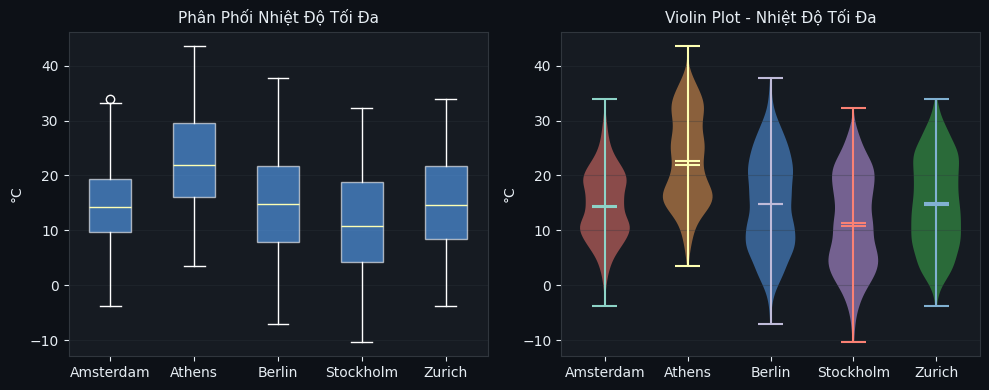

In [10]:
print_section_header("PHÂN PHỐI NHIỆT ĐỘ TỐI ĐA THEO THÀNH PHỐ")

fig_dist = plot_temperature_distribution(df, 'TempMax')
plt.show()

Dựa trên biểu đồ Boxplot và Violin Plot của biến `TempMax`, chúng ta rút ra các bằng chứng chiến lược sau:

1. **Sự phân hóa địa lý tuyệt đối (Minh chứng cho ANOVA):**
   * **Bằng chứng:** Dải nhiệt độ của Athens (hộp màu nâu) nằm ở phân khúc cao nhất (trung vị $\approx 22^\circ\text{C}$), trong khi Stockholm (hộp màu tím) nằm thấp hẳn xuống dưới (trung vị $\approx 10^\circ\text{C}$). Hầu như không có sự chồng lấn lớn giữa cực nóng và cực lạnh.
   * **Nhận định:** Bức tranh này giải thích hoàn hảo cho giá trị $F$-statistic khổng lồ trong phép thử ANOVA. Biến `City` thực sự tạo ra các phân vùng nhiệt độ biệt lập, khẳng định đây là một đặc trưng mang tính quyết định cho mô hình hồi quy.

2. **Hình dáng phân phối phi chuẩn (Minh chứng cho Jarque-Bera):**
   * **Bằng chứng:** Biểu đồ Violin cho thấy mật độ dữ liệu không có dạng hình chuông đối xứng hoàn hảo. Ví dụ, Athens có phần "đuôi" kéo rất dài lên mức trên $40^\circ\text{C}$ (Nắng nóng cực đoan), trong khi Stockholm có phần "bụng" phình to ở mức nhiệt thấp.
   * **Nhận định:** Nếu gộp chung 5 thành phố này lại, chúng ta chắc chắn sẽ có một phân phối đa đỉnh và lệch. Điều này củng cố quyết định tránh xa các mô hình tuyến tính đơn giản và hướng tới các thuật toán bền bỉ (Robust) như Ensemble Learning hoặc SVR.

## 6.4.2. Xu hướng chu kỳ theo thời gian

**Mục đích:** Sau khi đã thấy sự khác biệt về mặt phân bố tổng thể, chúng ta cần đưa yếu tố **Thời gian (Tháng)** vào hệ quy chiếu. Biểu đồ đường này được thiết kế để giải đáp hai câu hỏi:
* Tính chu kỳ mùa vụ của các thành phố châu Âu có đồng nhất với nhau không?
* Khoảng cách chênh lệch nhiệt độ giữa các thành phố có được duy trì ổn định trong suốt 12 tháng hay không?


           XU HƯỚNG NHIỆT ĐỘ THEO THÁNG GIỮA CÁC THÀNH PHỐ            



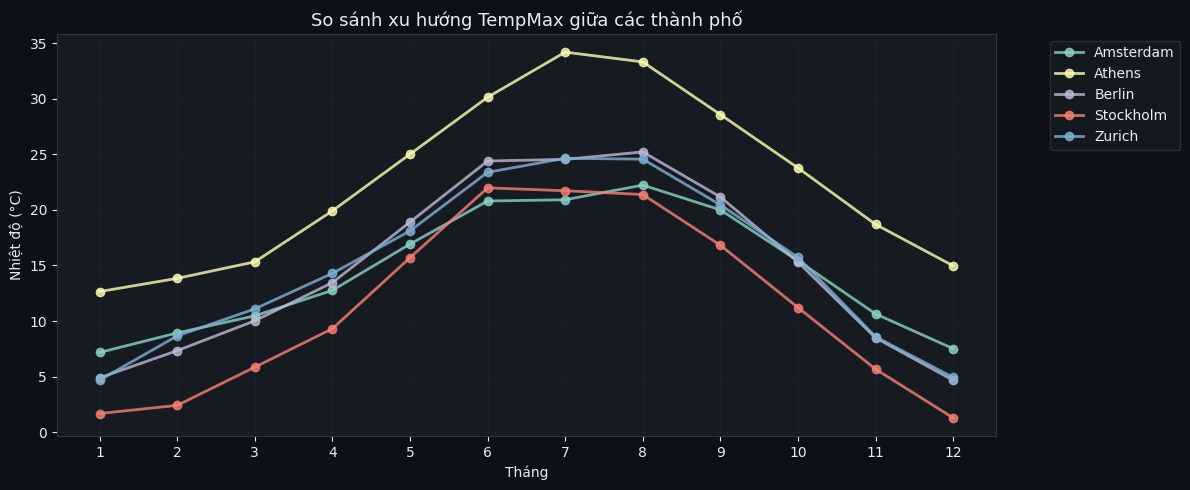

In [11]:
print_section_header("XU HƯỚNG NHIỆT ĐỘ THEO THÁNG GIỮA CÁC THÀNH PHỐ")

fig_trend = plot_city_comparison_trend(df, 'TempMax')
plt.show()

Quan sát quỹ đạo của 5 đường biểu diễn nhiệt độ cực đại qua 12 tháng, chúng ta có thể khẳng định:

1. **Tính chu kỳ hình sin hoàn hảo:**
   * **Bằng chứng:** Cả 5 thành phố đều tuân theo một quy luật tăng giảm đồng nhất, tạo đáy vào tháng 1-2 (Mùa đông) và đạt đỉnh vào tháng 7-8 (Mùa hè). 
   * **Nhận định:** Điều này xác nhận biến `Month` chứa đựng thông tin mang tính chu kỳ vật lý cực kỳ mạnh. Mô hình có thể dùng biến này làm "la bàn" để thiết lập mức nhiệt độ cơ sở cho dự báo.

2. **Sự phân tầng khí hậu ổn định:**
   * **Bằng chứng:** Các đường xu hướng di chuyển gần như song song và **không bao giờ cắt nhau**. Athens luôn duy trì vị trí độc tôn ở trên cùng, tạo một khoảng cách an toàn so với cụm 3 thành phố giữa (Amsterdam, Berlin, Zurich), và Stockholm thì luôn nằm dưới đáy.
   * **Nhận định:** Mối quan hệ giữa các thành phố mang tính cộng gộp và rất ổn định theo thời gian. Khí hậu không có hiện tượng "đảo chiều" bất ngờ giữa các vùng. Sự trật tự này là một "món quà" cho các thuật toán học máy, giúp chúng phân tách các quy luật dễ dàng hơn và giảm thiểu sai số dự báo.

## 6.4.3. PHÂN TÍCH TƯƠNG QUAN ĐA BIẾN

**Mục đích:** Sau khi đã hiểu được hình dáng và xu hướng của từng biến riêng lẻ, chúng ta sử dụng Ma trận tương quan để đánh giá mối quan hệ tuyến tính "đan chéo" giữa tất cả các biến số học.
* Lựa chọn đặc trưng: Tìm ra những biến có sức ảnh hưởng mạnh nhất tới biến mục tiêu `TempMax`.
* Nhận diện đa cộng tuyến: Phát hiện các biến đầu vào quá giống nhau, từ đó loại bỏ bớt để tránh làm nhiễu các thuật toán Hồi quy tuyến tính.


                          MA TRẬN TƯƠNG QUAN                          



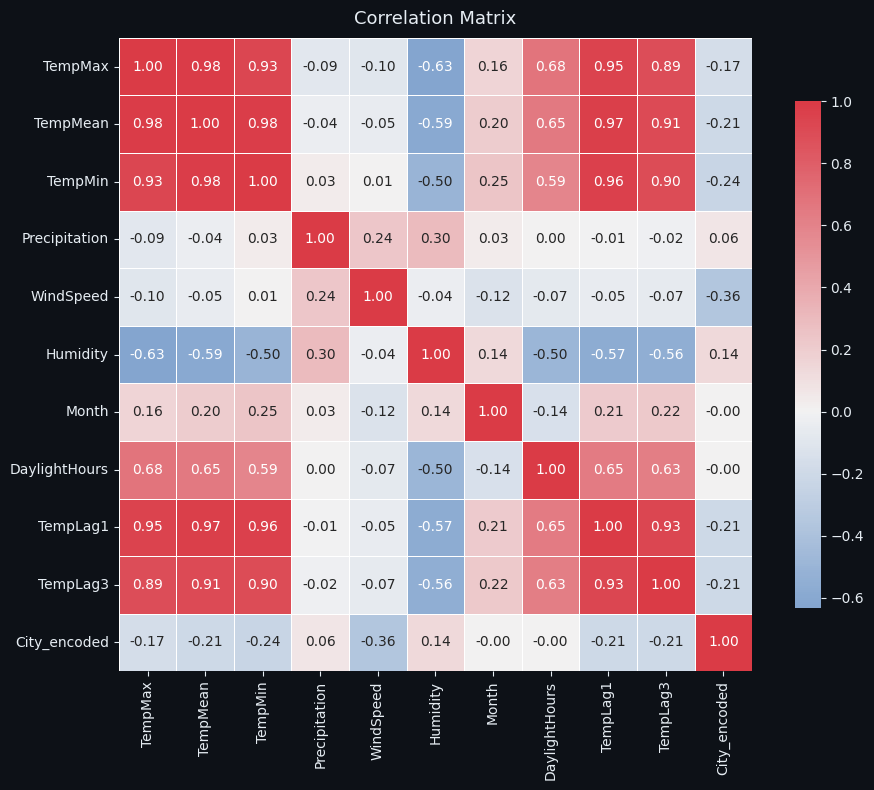

In [12]:
print_section_header("MA TRẬN TƯƠNG QUAN")

fig_corr = plot_correlation_heatmap(df)
plt.show()

Từ biểu đồ nhiệt, chúng ta có thể thiết lập ngay chiến lược chọn lọc đặc trưng dựa trên các bằng chứng toán học sau:

1. **Nhóm động lực chính:**
   * **Bằng chứng:** `TempLag1` có độ tương quan dương khổng lồ với `TempMax` ($r = 0.95$), kế đến là `TempLag3` ($r = 0.89$) và `DaylightHours` ($r = 0.68$).
   * **Nhận định:** Dữ liệu có tính tự hồi quy cực mạnh. Nhiệt độ của ngày hôm nay phụ thuộc rất lớn vào nhiệt độ của ngày hôm qua. Đồng thời, chu kỳ thiên văn (Giờ chiếu sáng) là một bệ phóng tuyến tính hoàn hảo cho nhiệt độ.

2. **Nhóm ức chế tuyến tính:**
   * **Bằng chứng:** `Humidity` có tương quan âm rất mạnh với `TempMax` ($r = -0.63$). 
   * **Nhận định:** Điều này củng cố tính hợp lý của các quy luật nhiệt động lực học: không khí càng khô (độ ẩm thấp) thì khả năng hấp thụ và bức xạ nhiệt bề mặt càng cao, đẩy nhiệt độ cực đại lên các đỉnh mới.

3. **Cảnh báo Đa cộng tuyến:**
   * **Bằng chứng:** Các biến `TempMax`, `TempMean` và `TempMin` có tương quan chéo với nhau gần như tuyệt đối ($r > 0.93$).
   * **Nhận định:** Nếu chúng ta muốn dự báo `TempMax`, chúng ta tuyệt đối **không được** đưa `TempMean` và `TempMin` của cùng ngày hôm đó vào mô hình để tránh hiện tượng rò rỉ dữ liệu và làm sai lệch trọng số mô hình.

4. **Giới hạn của tương quan Pearson đối với dữ liệu định danh:**
   * **Bằng chứng:** Biến `City_encoded` có tương quan tuyến tính rất thấp với `TempMax` ($r = -0.17$), dù trước đó kiểm định ANOVA đã chứng minh sức mạnh của nó ($F \approx 496$).
   * **Nhận định:** Tương quan Pearson chỉ đo lường được quan hệ *tuyến tính* (tăng/giảm dần đều). Vì `City_encoded` (0, 1, 2, 3, 4) là dữ liệu định danh không có tính thứ bậc thực sự, Pearson không thể nhận diện được sức mạnh của nó. Điều này là bằng chứng thép cho thấy: để tận dụng tối đa biến địa lý này, **mô hình dựa trên cây quyết định (Random Forest/XGBoost)** sẽ có ưu thế tuyệt đối so với Linear Regression.

## 6.4 Phân tích đặc trưng mùa và nhiệt độ chi tiết của từng thành phố

**Mục đích:** Ở biểu đồ trước, chúng ta mới chỉ so sánh `TempMax` giữa các thành phố. Trong bước cuối cùng của quy trình khám phá dữ liệu này, chúng ta sẽ xem rõ cấu trúc vi mô của từng thành phố bằng cách xem đồng thời 3 dải nhiệt độ: Tối đa (Max), Trung bình (Mean) và Tối thiểu (Min). Mục tiêu là:
* Đánh giá **Biên độ nhiệt ngày** thông qua khoảng cách giữa đỉnh và đáy (vùng được tô màu).
* Tìm kiếm bằng chứng vật lý về sự biến thiên phương sai theo thời gian, từ đó dự báo trước những rủi ro về sai số cho các mô hình hồi quy.


             PHÂN TÍCH QUY LUẬT MÙA CỦA TẤT CẢ THÀNH PHỐ              



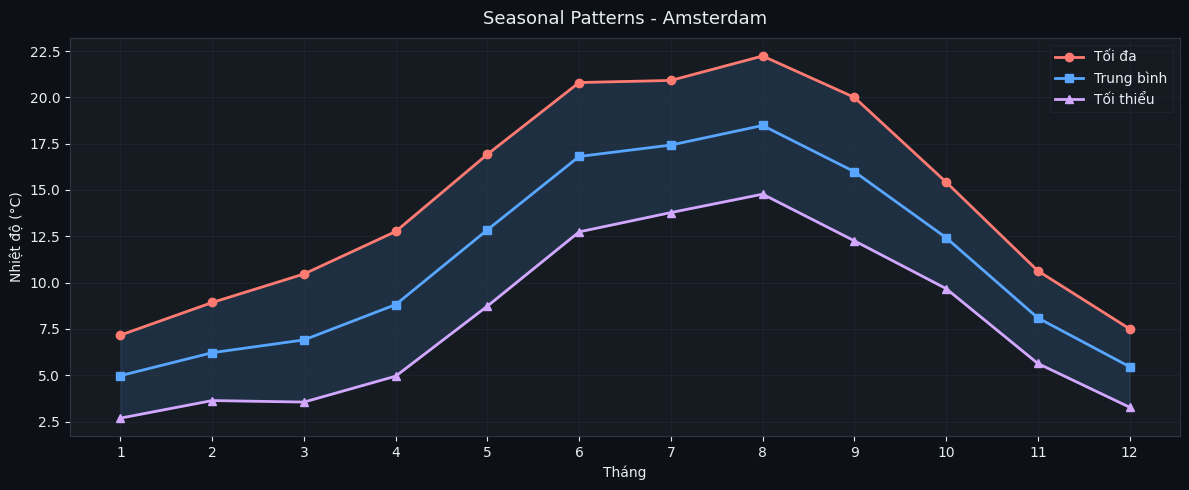

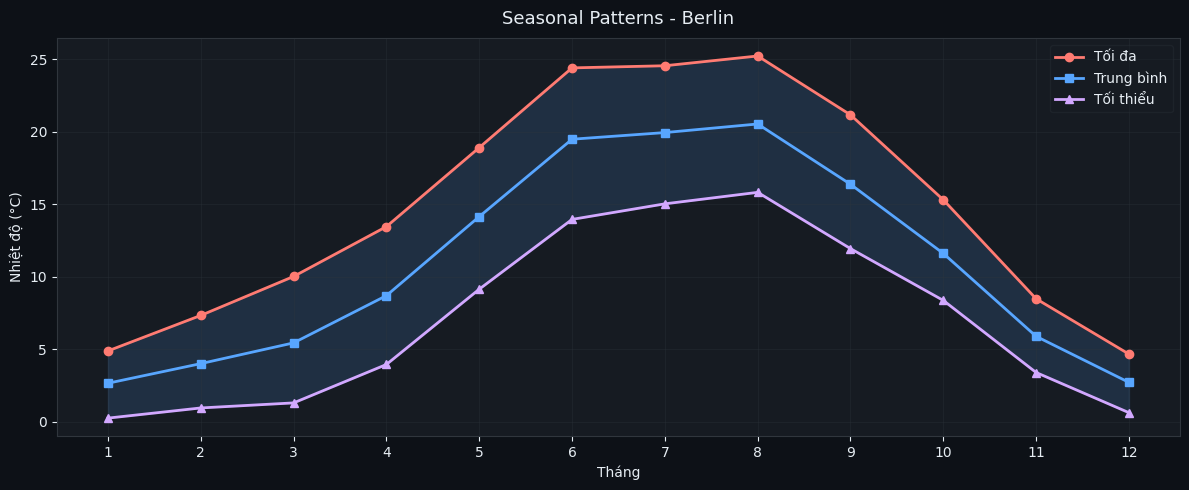

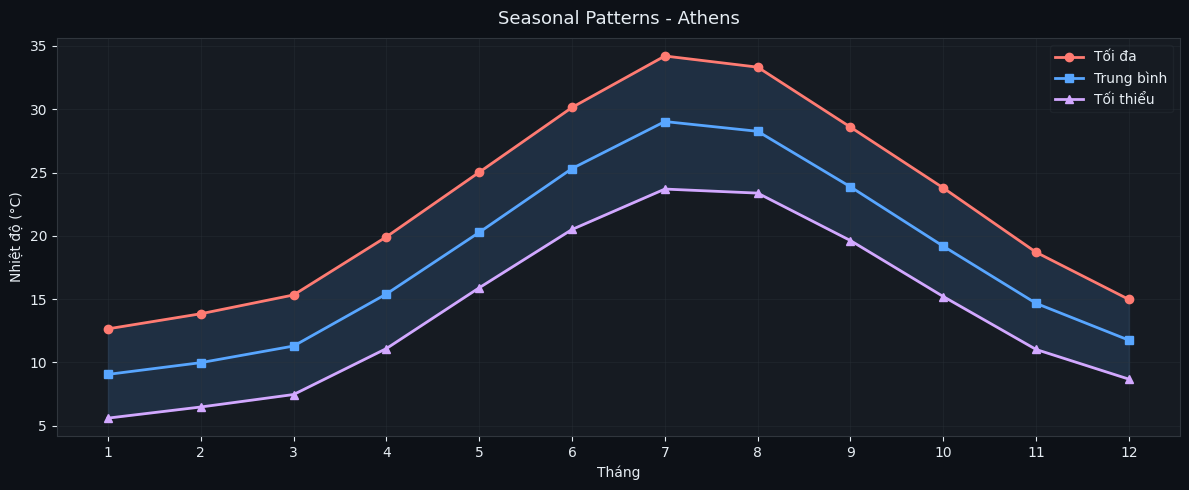

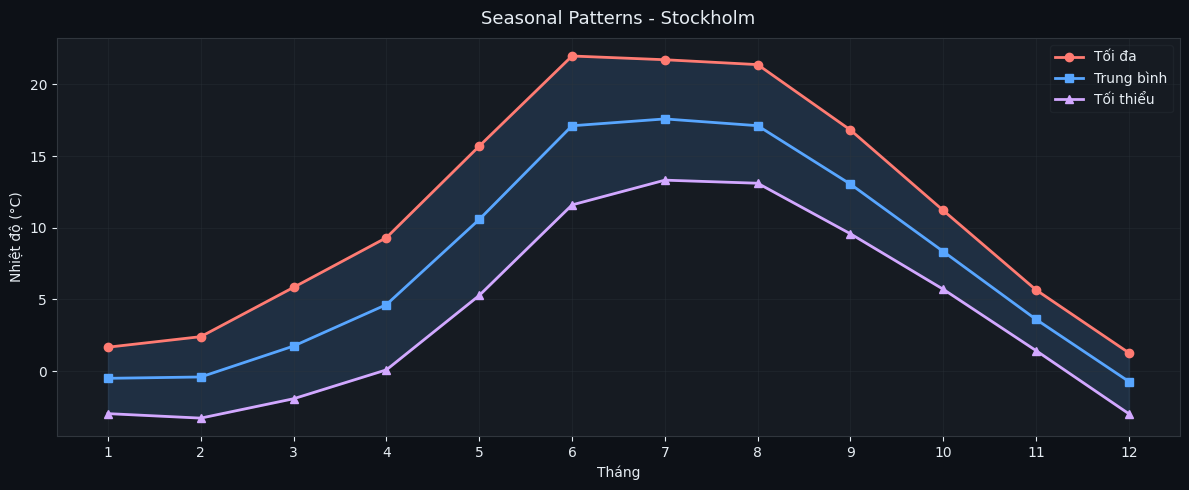

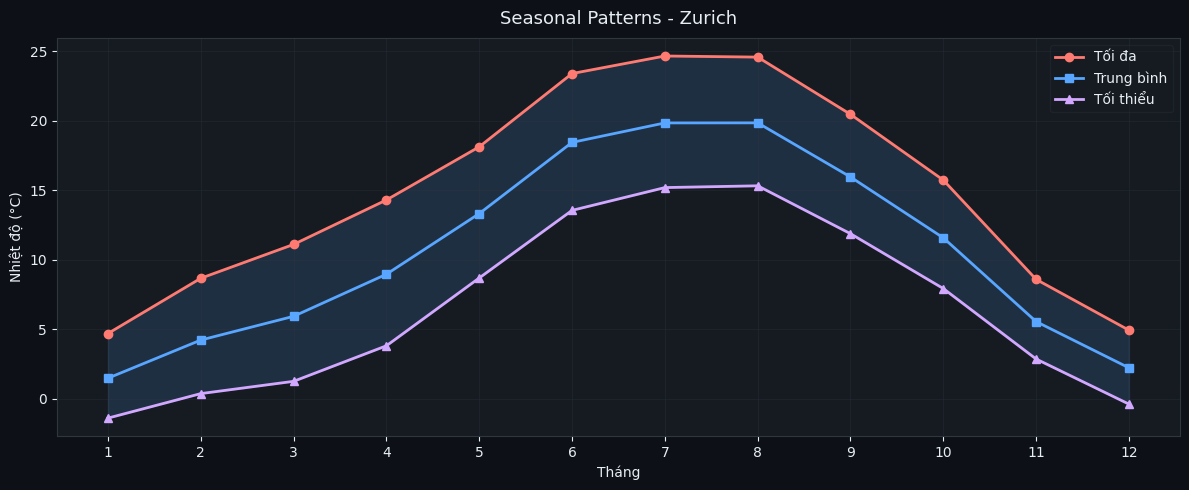

In [13]:
print_section_header("PHÂN TÍCH QUY LUẬT MÙA CỦA TẤT CẢ THÀNH PHỐ")

representative_cities = ['Amsterdam', 'Berlin', 'Athens', 'Stockholm', 'Zurich']

for city in representative_cities:
    fig = plot_seasonal_patterns(df, city, figsize=(12, 5))
    plt.show()

Quan sát 5 biểu đồ chu kỳ nhiệt độ, chúng ta thu thập được những bằng chứng giá trị cuối cùng để thiết lập chiến lược huấn luyện mô hình:

1. **Khẳng định tính chất Đa cộng tuyến hoàn hảo:**
   * **Bằng chứng:** Ở cả 5 thành phố, ba đường `TempMax`, `TempMean` và `TempMin` di chuyển song song một cách tuyệt đối, gần như không có bất kỳ điểm giao cắt nào trong suốt 12 tháng.
   * **Nhận định:** Bức tranh này minh chứng trực quan cho các hệ số tương quan $r > 0.93$ trong Heatmap. Việc đưa cả 3 biến này vào cùng một không gian vector đầu vào sẽ gây ra sự dư thừa thông tin nghiêm trọng. Trong pha xây dựng mô hình tới đây, chúng ta sẽ chỉ chọn một biến làm mục tiêu và loại bỏ các biến đồng cấp trong cùng một khung thời gian.

2. **Sự nở rộng của Biên độ nhiệt:**
   * **Bằng chứng:** Hãy nhìn vào "bề dày" của vùng không gian được tô màu (khoảng cách từ Min đến Max). Ở Athens, vùng này giãn rất rộng (chênh lệch có thể lên tới $10-15^\circ\text{C}$ trong những tháng mùa hè). Ngược lại, ở Amsterdam, dải băng này hẹp hơn và duy trì độ dày khá đồng đều qua các tháng. Ngoài ra, các tháng mùa đông (11, 12, 1) tại Stockholm và Zurich có xu hướng hội tụ, dải băng hẹp lại rõ rệt.
   * **Nhận định:** Đây là một phát hiện cực kỳ đắt giá về mặt thống kê (hiện tượng Phương sai thay đổi). Điều này báo trước một "giới hạn" của mô hình: Các mô hình thôn minh sẽ dự báo cực kỳ chính xác vào mùa đông hoặc tại các vùng ôn đới như Amsterdam (do dao động nhiệt trong ngày thấp), nhưng sai số (MAE/MSE) chắc chắn sẽ "phình to" hơn khi dự báo cho Athens vào mùa hè do độ nhiễu và biên độ dao động tự nhiên của bầu khí quyển tại đây quá lớn.

---
# PHÂN TÍCH HỒI QUY
---

## 7.1 Chiến lược xây dựng các mô hình

Sau quá trình khám phá dữ liệu (EDA) và kiểm định thống kê chuyên sâu, chúng ta đã xác lập được tính chất của tập dữ liệu thời tiết này với 3 đặc điểm thách thức:

1. **Tính phi chuẩn:** Kiểm định Jarque-Bera bác bỏ giả thuyết phân phối chuẩn ($JB \approx 103.45$).
    
2. **Sự phân hóa địa lý cực đoan:** ANOVA xác nhận `City` là biến quan trọng nhất ($F \approx 496.38$), nhưng tương quan tuyến tính Pearson lại không thể hiện rõ điều này.
    
3. **Hiện tượng Đa cộng tuyến:** Các biến trễ (`TempLag1`, `TempLag3`) có tương quan cực mạnh ($r > 0.90$), gây rủi ro nhiễu cho các mô hình hồi quy truyền thống.
    

Do đó, chúng ta quyết định triển khai một hệ thống dự báo đa thuật toán, trong đó mỗi mô hình được lựa chọn để giải quyết một bài toán cụ thể.

### 7.1.1 Nhóm mô hình Tuyến tính và Khoảng cách (Baseline Models)

- **Ridge Regression (L2 Regularization):** Chúng ta chọn Ridge thay vì OLS (Ordinary Least Squares) để đối phó với hiện tượng đa cộng tuyến. Bằng cách thêm thành phần phạt, Ridge sẽ kiểm soát các trọng số của các biến trễ, giúp mô hình ổn định và tránh Overfitting.
    
- **K-Nearest Neighbors (KNN):** Được sử dụng như một mô hình phi tham số, dựa trên giả thuyết về "tính tương đồng khí hậu". Nếu các chỉ số khí tượng (Độ ẩm, Giờ chiếu sáng) hôm nay giống với một ngày trong quá khứ, nhiệt độ cũng sẽ có xu hướng tương đương.
    

### 7.1.2 Nhóm mô hình Phi tuyến và Hàm nhân (Advanced Kernel Models)

- **Support Vector Regression (SVR) với RBF Kernel:** Đây là mô hình chủ lực để đối phó với kết quả của Jarque-Bera. Vì dữ liệu không chuẩn và có mối quan hệ phi tuyến giữa các biến (như độ ẩm vs nhiệt độ), hàm nhân RBF (Radial Basis Function) sẽ nâng dữ liệu vào không gian cao chiều để tìm ra mặt phẳng hồi quy tối ưu mà các mô hình tuyến tính không thể thấy được.
    

### 7.1.3 Nhóm mô hình Dựa trên Cây (Ensemble Learning)

- **Random Forest & XGBoost:** Đây là lựa chọn chiến lược để khai thác biến định danh `City`. Khác với các mô hình toán học thuần túy dễ bị đánh lừa bởi giá trị số của `City_encoded`, các mô hình Cây thực hiện phân nhánh dựa trên logic, giúp nắm bắt trọn vẹn sự phân hóa địa lý đã tìm thấy trong ANOVA. Ngoài ra, cơ chế Boosting của XGBoost sẽ giúp mô hình học từ các sai số của những ngày thời tiết biến động mạnh.

## 7.2 Các chỉ số đánh giá

Để đo lường hiệu quả một cách khách quan, chúng ta sử dụng bộ 3 chỉ số:

1. **$R^2$ (Coefficient of Determination):** Đo lường tỷ lệ phần trăm sự biến thiên của nhiệt độ mà mô hình giải thích được (Kỳ vọng $> 0.90$).
    
2. **MAE (Mean Absolute Error):** Sai số tuyệt đối trung bình (tính bằng $^\circ$C), cho biết trung bình mô hình dự báo lệch bao nhiêu độ so với thực tế (Kỳ vọng $< 1.5^\circ$C).
    
3. **MSE (Mean Squared Error):** Hình phạt nặng hơn cho các sai số lớn, giúp chúng ta đánh giá độ ổn định của mô hình khi gặp các ngày nhiệt độ cực đoan.

In [ ]:
training_results = train_all_models(df)
save_all_models(training_results)


                      HUẤN LUYỆN TẤT CẢ MÔ HÌNH                       


                         TRAINING ALL MODELS                          


TARGET: TempMax
Train: 7308 samples | Test: 1827 samples
   Training Ridge... R²=0.9107, MAE=1.9975
   Training KNN... R²=0.9082, MAE=2.0305
   Training Random Forest... R²=0.9212, MAE=1.8567
   Training XGBoost... R²=0.9267, MAE=1.8082
   Training SVR... R²=0.9264, MAE=1.7925

TARGET: TempMean
Train: 7308 samples | Test: 1827 samples
   Training Ridge... R²=0.9372, MAE=1.4693
   Training KNN... R²=0.9311, MAE=1.5711
   Training Random Forest... R²=0.9422, MAE=1.4244
   Training XGBoost... R²=0.9463, MAE=1.3767
   Training SVR... R²=0.9489, MAE=1.3292

TARGET: TempMin
Train: 7308 samples | Test: 1827 samples
   Training Ridge... R²=0.9192, MAE=1.5841
   Training KNN... R²=0.9058, MAE=1.7132
   Training Random Forest... R²=0.9234, MAE=1.5312
   Training XGBoost... R²=0.9267, MAE=1.4847
   Training SVR... R²=0.9288, MAE=1.4662

HOÀN THÀNH TRAI


                SO SÁNH HIỆU NĂNG GIỮA CÁC THUẬT TOÁN                 



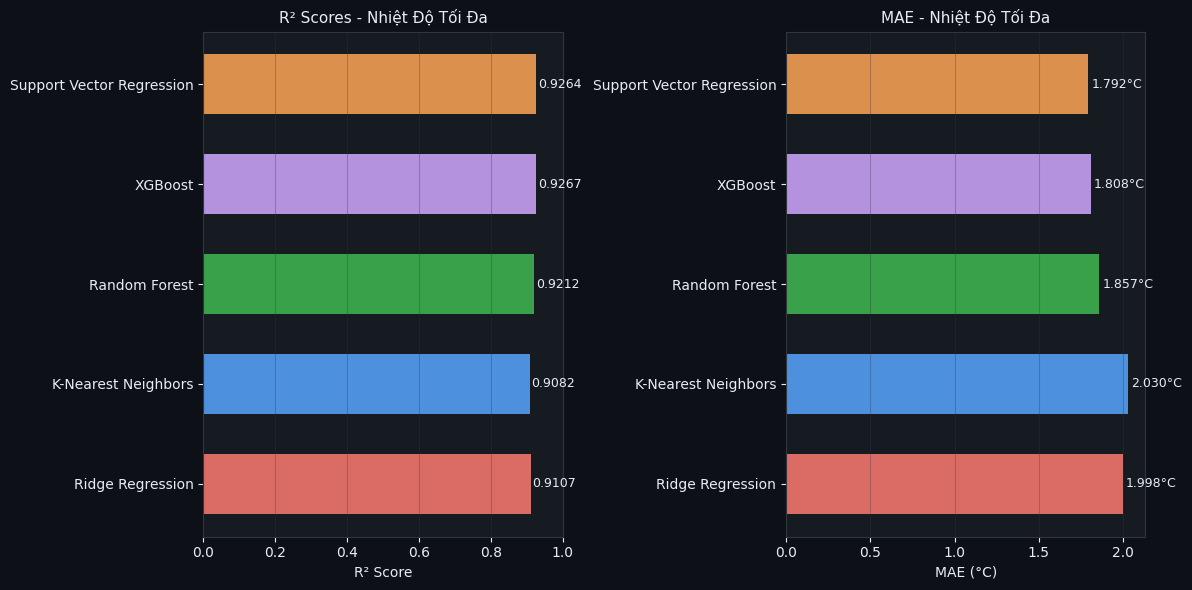

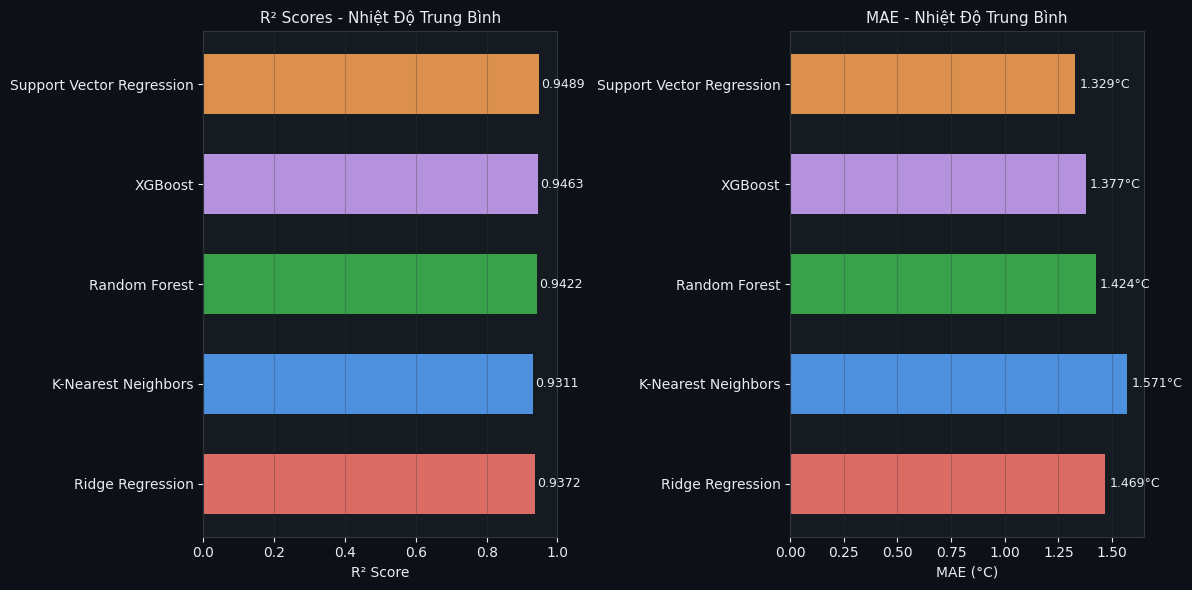

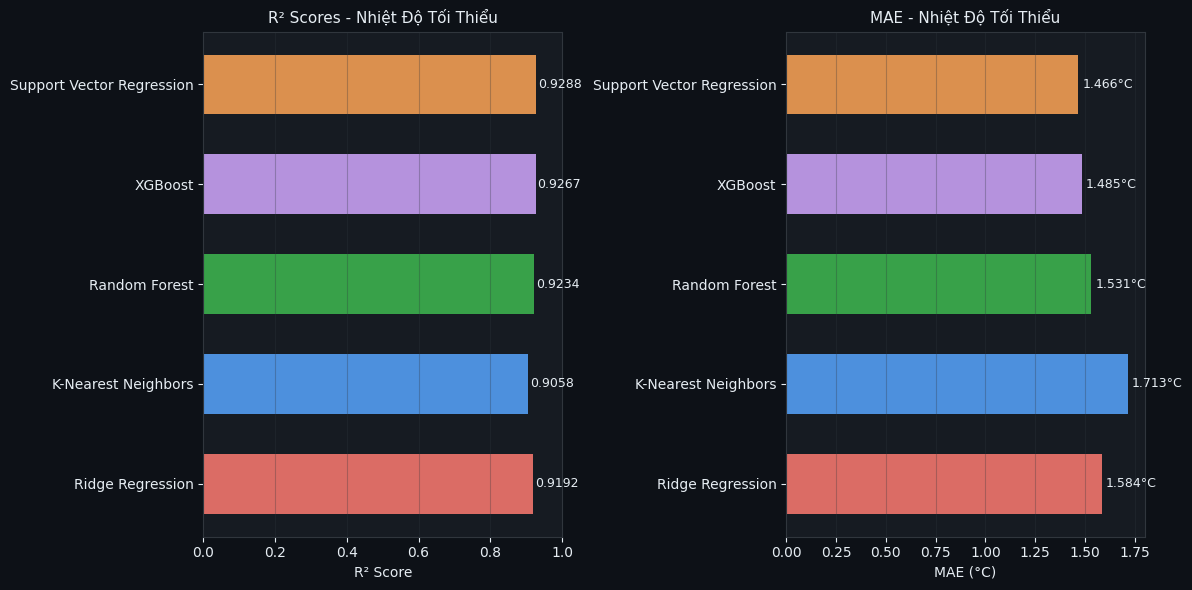

In [21]:
print_section_header("SO SÁNH HIỆU NĂNG GIỮA CÁC THUẬT TOÁN")

metrics = load_evaluation_metrics()

fig_comp_tmax = plot_model_comparison(metrics, target='TempMax', figsize=(12, 6))
plt.show()

fig_comp_tmean = plot_model_comparison(metrics, target='TempMean', figsize=(12, 6))
plt.show()

fig_comp_tmin = plot_model_comparison(metrics, target='TempMin', figsize=(12, 6))
plt.show()

In [22]:
print_evaluation_summary(training_results)


                          EVALUATION SUMMARY                          


TempMax
----------------------------------------------------------------------
Model                             R²        MAE       RMSE
----------------------------------------------------------------------
XGBoost                       0.9267     1.8082     2.3338
Support Vector Regression     0.9264     1.7925     2.3394
Random Forest                 0.9212     1.8567     2.4207
Ridge Regression              0.9107     1.9975     2.5768
K-Nearest Neighbors           0.9082     2.0305     2.6115

   Best: XGBoost (R²=0.9267)

TempMean
----------------------------------------------------------------------
Model                             R²        MAE       RMSE
----------------------------------------------------------------------
Support Vector Regression     0.9489     1.3292     1.7594
XGBoost                       0.9463     1.3767     1.8033
Random Forest                 0.9422     1.4244     1.8712
Ridg

## 7.3. Phân tích kết quả thực nghiệm

Dựa trên bảng tổng hợp Evaluation Summary với 3 hệ quy chiếu ($R^2$, MAE, RMSE), chúng ta có thể rút ra những đánh giá sắc bén về bản chất của mô hình và dữ liệu:

### 7.3.1 Hiệu năng tổng thể xuất sắc
* **Sức mạnh của Feature Engineering:** Toàn bộ 5 thuật toán đều xuất sắc vượt ngưỡng $R^2 > 0.90$ trên cả 3 mục tiêu dự báo. Điều này là bằng chứng thép cho thấy bộ đặc trưng chúng ta kiến tạo (đặc biệt là biến trễ `TempLag1` và `DaylightHours`) đã thâu tóm được gần như toàn bộ quy luật biến thiên của nhiệt độ.

### 7.3.2 Sự thống trị và cạnh tranh của các mô hình phi tuyến
* **SVR thống trị dải nhiệt độ ổn định:** Ở mục tiêu `TempMean` và `TempMin`, **Support Vector Regression (SVR)** mang lại giá trị dự báo với $R^2$ cao nhất (lên tới $0.9489$ cho TempMean) và sai số thấp nhất ($MAE \approx 1.33^\circ\text{C}$). Hàm nhân RBF đã xử lý cực kỳ mượt mà những biến thiên nhiệt độ mang tính chu kỳ và ổn định.
* **XGBoost tỏa sáng ở dải nhiệt độ cực đoan:** Khá bất ngờ nhưng hoàn toàn hợp lý, **XGBoost** lại vươn lên dẫn đầu ở mục tiêu khó nhằn nhất là `TempMax` ($R^2 = 0.9267$). Vì nhiệt độ cực đại thường chứa nhiều giá trị ngoại lai (những ngày nắng nóng đột biến), cơ chế học tăng cường kết hợp phân nhánh dạng cây của XGBoost đã chứng minh khả năng "chống chịu" nhiễu tốt hơn SVR.

### 7.3.3 Phân tích chuyên sâu: Khoảng cách giữa MAE và MSE
Việc đưa MSE vào đánh giá cho phép chúng ta phân tích rõ hơn độ ổn định của mô hình:
* **Bản chất của MSE:** MSE luôn phạt rất nặng các dự báo có sai số lớn. Nhìn vào bảng, MSE luôn cao hơn MAE khoảng $0.4^\circ\text{C}$ đến $0.5^\circ\text{C}$.
* **Biến động theo mục tiêu:** Hãy để ý độ chênh lệch giữa MSE và MAE. Ở mục tiêu `TempMean`, khoảng cách này của SVR là $\approx 0.43^\circ\text{C}$ ($1.7594 - 1.3292$). Tuy nhiên, ở `TempMax`, khoảng cách này của XGBoost dãn rộng lên $\approx 0.52^\circ\text{C}$ ($2.3338 - 1.8082$).
* **Nhận định:** Điều này khẳng định lại lý thuyết vật lý khí quyển: `TempMax` khó dự báo và có nhiều đỉnh nhiễu (outliers) hơn `TempMean`. Dù mô hình dự báo trung bình chỉ lệch $\sim 1.8^\circ\text{C}$ (MAE), nhưng thỉnh thoảng sẽ có những ngày thời tiết biến động cực đoan khiến mô hình chệch nhịp đáng kể, đẩy hình phạt RMSE lên mức $> 2.3^\circ\text{C}$.

### 7.3.4 Giới hạn của các mô hình cơ sở
* Ridge Regression và KNN dù làm rất tốt nhưng luôn đứng cuối bảng xếp hạng (MSE của KNN cho TempMax lên tới $> 2.6^\circ\text{C}$). Điều này chốt lại lập luận trước đây: Dữ liệu thời tiết chứa các quy luật phi tuyến tính phức tạp mà các mô hình toán học đơn giản không thể nội suy hoàn toàn.

## 7.4. Các hạn chế của mô hình

Chúng ta xác định các giới hạn sau:

1. **Tính phụ thuộc dữ liệu trễ:** Mô hình dựa rất mạnh vào `TempLag1`. Nếu xảy ra các hiện tượng thời tiết cực đoan đột ngột không theo quy luật (như bão lớn), mô hình sẽ gặp khó khăn trong việc phản ứng tức thì.
    
2. **Sự biến thiên sai số theo mục tiêu dự đoán:** Có thể thấy sai số MAE của `TempMax` (khoảng $1.8^\circ\text{C}$) luôn cao hơn `TempMean` ($1.3^\circ\text{C}$). Điều này phản ánh thực tế vật lý: nhiệt độ đỉnh điểm trong ngày luôn chịu nhiều tác động nhiễu (như mây che, cường độ nắng cục bộ) hơn là nhiệt độ trung bình.

---
# CÔNG CỤ PHÂN TÍCH
---

## 8.1. Chiến lược triển khai

Mục tiêu cuối cùng của một dự án Machine Learning không chỉ dừng lại ở các chỉ số MSE hay $R^2$ nằm trong code, mà phải mang lại giá trị thực tiễn cho người dùng cuối – những người không có kiến thức lập trình.

Để đáp ứng tiêu chí này, **Tableau** được lựa chọn làm công cụ xây dựng Dashboard tương tác. Quy trình triển khai diễn ra như sau:
1. **Model Inference:** Sử dụng mô hình tốt nhất (SVR/XGBoost) từ để dự báo trên toàn bộ tập dữ liệu kiểm thử.
2. **Data Export:** Đóng gói giá trị thực tế, giá trị dự báo và các đặc trưng thành một tệp `.csv` chuẩn hóa.
3. **Interactive Dashboard:** Đưa tệp dữ liệu vào Tableau để xây dựng giao diện trực quan, cho phép người dùng lọc theo Thành phố, Tháng và xem sai số mô hình một cách trực tiếp.

In [ ]:
# Gọi module chuyên dụng đã xây dựng trong thư mục dashboard
from src.dashboard.prepare_tableau import generate_tableau_dataset

tableau_master_path = generate_tableau_dataset()

📦 ĐANG ĐÓNG GÓI DỮ LIỆU DỰ BÁO CHO TABLEAU...
✅ Đã xuất thành công 1827 dòng dữ liệu!
📂 File được lưu tại: /home/Do_Phuc/FPTU/ADY201m/weather-ml-project/models/saved_models/tableau_export_predictions.csv
